# Final Project TUBerlin - Connor Waite

## Project Overview:
#### This project explores the relationships between NBA player salaries, career performance, draft position, age, playing position and team payrolls. 
#### The analysis combines historical salary records from 1985–86 to 2017–18 with player career statistics to create a consolidated dataset for analysis. 
#### We investigate ten analytical questions using a combination of descriptive statistics and interactive visualisations.

#### Dataset: https://www.kaggle.com/datasets/thedevastator/exploring-nba-player-performance-and-salaries-19/data?select=salaries_1985to2018.csv

# 1. Initial Import and Exploration of the Data

In [1219]:
# Import required packages
import pandas as pd
import seaborn as sns
import plotly.express as px

In [1220]:
df = pd.read_csv(r"C:\Users\waite\TUBERLIN2026\Course Resources\Project\players.csv")

In [1221]:
df.head()

,index,_id,birthDate,birthPlace,career_AST,career_FG%,career_FG3%,career_FT%,career_G,career_PER,...,draft_pick,draft_round,draft_team,draft_year,height,highSchool,name,position,shoots,weight
0,0,abdelal01,"June 24, 1968","Cairo, Egypt",0.3,50.2,0.0,70.1,256,13.0,...,25th overall,1st round,Portland Trail Blazers,1990,6-10,"Bloomfield in Bloomfield, New Jersey",Alaa Abdelnaby,Power Forward,Right,240lb
1,1,abdulza01,"April 7, 1946","Brooklyn, New York",1.2,42.8,NaN,72.8,505,15.1,...,5th overall,1st round,Cincinnati Royals,1968,6-9,"John Jay in Brooklyn, New York",Zaid Abdul-Aziz,Power Forward and Center,Right,235lb
2,2,abdulka01,"April 16, 1947","New York, New York",3.6,55.9,5.6,72.1,1560,24.6,...,1st overall,1st round,Milwaukee Bucks,1969,7-2,"Power Memorial in New York, New York",Kareem Abdul-Jabbar,Center,Right,225lb
3,3,abdulma02,"March 9, 1969","Gulfport, Mississippi",3.5,44.2,35.4,90.5,586,15.4,...,3rd overall,1st round,Denver Nuggets,1990,6-1,"Gulfport in Gulfport, Mississippi",Mahmoud Abdul-Rauf,Point Guard,Right,162lb
4,4,abdulta01,"November 3, 1974","Maisons Alfort, France",1.1,41.7,23.7,70.3,236,11.4,...,11th overall,1st round,Sacramento Kings,1997,6-6,"Lycee Aristide Briand in Evreux, France",Tariq Abdul-Wahad,Shooting Guard,Right,223lb


In [1222]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4685 entries, 0 to 4684
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   index        4685 non-null   int64  
 1   _id          4685 non-null   object 
 2   birthDate    4657 non-null   object 
 3   birthPlace   4185 non-null   object 
 4   career_AST   4685 non-null   float64
 5   career_FG%   4685 non-null   object 
 6   career_FG3%  3557 non-null   object 
 7   career_FT%   4685 non-null   object 
 8   career_G     4685 non-null   int64  
 9   career_PER   4685 non-null   object 
 10  career_PTS   4685 non-null   float64
 11  career_TRB   4685 non-null   object 
 12  career_WS    4685 non-null   object 
 13  career_eFG%  3557 non-null   object 
 14  college      4372 non-null   object 
 15  draft_pick   3369 non-null   object 
 16  draft_round  3507 non-null   object 
 17  draft_team   3507 non-null   object 
 18  draft_year   3306 non-null   object 
 19  height

In [1223]:
df2 = pd.read_csv(r"C:\Users\waite\TUBERLIN2026\Course Resources\Project\salaries_1985to2018.csv")

In [1224]:
df2.head()

,index,league,player_id,salary,season,season_end,season_start,team
0,0,NBA,abdelal01,395000,1990-91,1991,1990,Portland Trail Blazers
1,1,NBA,abdelal01,494000,1991-92,1992,1991,Portland Trail Blazers
2,2,NBA,abdelal01,500000,1992-93,1993,1992,Boston Celtics
3,3,NBA,abdelal01,805000,1993-94,1994,1993,Boston Celtics
4,4,NBA,abdelal01,650000,1994-95,1995,1994,Sacramento Kings


In [1225]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14163 entries, 0 to 14162
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   index         14163 non-null  int64 
 1   league        14163 non-null  object
 2   player_id     14163 non-null  object
 3   salary        14163 non-null  int64 
 4   season        14163 non-null  object
 5   season_end    14163 non-null  int64 
 6   season_start  14163 non-null  int64 
 7   team          14159 non-null  object
dtypes: int64(4), object(4)
memory usage: 885.3+ KB


# 2. Preparing and Tidying the Data

In [1227]:
players = df.copy()

In [1228]:
salaries = df2.copy()

### Remove unecessary index column

In [1230]:
players = players.drop(columns="index")

In [1231]:
salaries = salaries.drop(columns="index")

In [1232]:
players.head()

,_id,birthDate,birthPlace,career_AST,career_FG%,career_FG3%,career_FT%,career_G,career_PER,career_PTS,...,draft_pick,draft_round,draft_team,draft_year,height,highSchool,name,position,shoots,weight
0,abdelal01,"June 24, 1968","Cairo, Egypt",0.3,50.2,0.0,70.1,256,13.0,5.7,...,25th overall,1st round,Portland Trail Blazers,1990,6-10,"Bloomfield in Bloomfield, New Jersey",Alaa Abdelnaby,Power Forward,Right,240lb
1,abdulza01,"April 7, 1946","Brooklyn, New York",1.2,42.8,NaN,72.8,505,15.1,9.0,...,5th overall,1st round,Cincinnati Royals,1968,6-9,"John Jay in Brooklyn, New York",Zaid Abdul-Aziz,Power Forward and Center,Right,235lb
2,abdulka01,"April 16, 1947","New York, New York",3.6,55.9,5.6,72.1,1560,24.6,24.6,...,1st overall,1st round,Milwaukee Bucks,1969,7-2,"Power Memorial in New York, New York",Kareem Abdul-Jabbar,Center,Right,225lb
3,abdulma02,"March 9, 1969","Gulfport, Mississippi",3.5,44.2,35.4,90.5,586,15.4,14.6,...,3rd overall,1st round,Denver Nuggets,1990,6-1,"Gulfport in Gulfport, Mississippi",Mahmoud Abdul-Rauf,Point Guard,Right,162lb
4,abdulta01,"November 3, 1974","Maisons Alfort, France",1.1,41.7,23.7,70.3,236,11.4,7.8,...,11th overall,1st round,Sacramento Kings,1997,6-6,"Lycee Aristide Briand in Evreux, France",Tariq Abdul-Wahad,Shooting Guard,Right,223lb


In [1233]:
salaries.head()

,league,player_id,salary,season,season_end,season_start,team
0,NBA,abdelal01,395000,1990-91,1991,1990,Portland Trail Blazers
1,NBA,abdelal01,494000,1991-92,1992,1991,Portland Trail Blazers
2,NBA,abdelal01,500000,1992-93,1993,1992,Boston Celtics
3,NBA,abdelal01,805000,1993-94,1994,1993,Boston Celtics
4,NBA,abdelal01,650000,1994-95,1995,1994,Sacramento Kings


### Ensure both id columns share the same name

In [1235]:
players = players.rename(columns={"_id": "player_id"})

In [1236]:
players.head()

,player_id,birthDate,birthPlace,career_AST,career_FG%,career_FG3%,career_FT%,career_G,career_PER,career_PTS,...,draft_pick,draft_round,draft_team,draft_year,height,highSchool,name,position,shoots,weight
0,abdelal01,"June 24, 1968","Cairo, Egypt",0.3,50.2,0.0,70.1,256,13.0,5.7,...,25th overall,1st round,Portland Trail Blazers,1990,6-10,"Bloomfield in Bloomfield, New Jersey",Alaa Abdelnaby,Power Forward,Right,240lb
1,abdulza01,"April 7, 1946","Brooklyn, New York",1.2,42.8,NaN,72.8,505,15.1,9.0,...,5th overall,1st round,Cincinnati Royals,1968,6-9,"John Jay in Brooklyn, New York",Zaid Abdul-Aziz,Power Forward and Center,Right,235lb
2,abdulka01,"April 16, 1947","New York, New York",3.6,55.9,5.6,72.1,1560,24.6,24.6,...,1st overall,1st round,Milwaukee Bucks,1969,7-2,"Power Memorial in New York, New York",Kareem Abdul-Jabbar,Center,Right,225lb
3,abdulma02,"March 9, 1969","Gulfport, Mississippi",3.5,44.2,35.4,90.5,586,15.4,14.6,...,3rd overall,1st round,Denver Nuggets,1990,6-1,"Gulfport in Gulfport, Mississippi",Mahmoud Abdul-Rauf,Point Guard,Right,162lb
4,abdulta01,"November 3, 1974","Maisons Alfort, France",1.1,41.7,23.7,70.3,236,11.4,7.8,...,11th overall,1st round,Sacramento Kings,1997,6-6,"Lycee Aristide Briand in Evreux, France",Tariq Abdul-Wahad,Shooting Guard,Right,223lb


In [1237]:
players.shape

(4685, 24)

In [1238]:
salaries.shape

(14163, 7)

### Ensure there are no missing or duplicated IDs, and that all are unique

In [1240]:
players["player_id"].isna().sum()

0

In [1241]:
players["player_id"].duplicated().sum()

0

In [1242]:
players["player_id"].nunique()

4685

In [1243]:
salaries["player_id"].isna().sum()

0

In [1244]:
salaries["player_id"].duplicated().sum()

11755

In [1245]:
salaries["player_id"].nunique()

2408

In [1246]:
salaries.duplicated().sum()

0

### Before aggregating salaries, check if players appear more than once for the same season

In [1248]:
player_season_counts = (
    salaries.groupby(["player_id", "season"])
    .size()
    .reset_index(name="number_of_rows")
)

player_season_counts.head()

,player_id,season,number_of_rows
0,abdelal01,1990-91,1
1,abdelal01,1991-92,1
2,abdelal01,1992-93,1
3,abdelal01,1993-94,1
4,abdelal01,1994-95,1


In [1249]:
# Check specifically for cases with more than 1 row
multiple_player_seasons = player_season_counts[
    player_season_counts["number_of_rows"] > 1
]

multiple_player_seasons

,player_id,season,number_of_rows
53,acyqu01,2016-17,2
97,afflaar01,2017-18,2
109,aguirma01,1993-94,2
250,alstora01,2009-10,2
268,amundlo01,2006-07,3
...,...,...,...
13601,woolror01,1993-94,2
13610,workmha01,1998-99,2
13637,wrighbr03,2017-18,2
13683,wroteto01,2015-16,2


### We can see that 385 such players exist 
### Now examine the repeated player seasons

In [1251]:
duplicate_summary = (
    salaries.groupby(["player_id", "season"])
    .agg(
        number_of_rows=("salary", "size"),
        number_of_teams=("team", "nunique"),
        number_of_salary_values=("salary", "nunique"),
        minimum_salary=("salary", "min"),
        maximum_salary=("salary", "max")
    )
    .reset_index()
)

duplicate_summary = duplicate_summary[
    duplicate_summary["number_of_rows"] > 1
]

duplicate_summary.head(10)

,player_id,season,number_of_rows,number_of_teams,number_of_salary_values,minimum_salary,maximum_salary
53,acyqu01,2016-17,2,2,2,1050961,1914544
97,afflaar01,2017-18,2,2,2,1471382,1500000
109,aguirma01,1993-94,2,2,2,150000,1471000
250,alstora01,2009-10,2,2,2,753133,4300000
268,amundlo01,2006-07,3,3,3,35232,105696
294,anderch01,2012-13,2,2,2,699952,4526000
309,anderde01,2005-06,2,2,2,1670000,9093000
310,anderde01,2006-07,3,3,3,400000,9742500
319,andergr01,1994-95,2,2,2,110000,400000
325,anderja01,2012-13,2,2,2,145749,472427


### We can see that some players have multiple salaries for 1 season
### We can also see this matches the number of teams for that season

In [1253]:
# Inspecting the actual rows to ensure this is true
multiple_salary_rows = (
    salaries.merge(
        multiple_player_seasons[["player_id", "season"]],
        on=["player_id", "season"],
        how="inner"
    )
    .merge(
        players[["player_id", "name"]],
        on="player_id",
        how="left"
    )
    .sort_values(["player_id", "season", "salary"])
)

multiple_salary_rows[
    ["player_id", "name", "season", "team", "salary"]
].head(10)

,player_id,name,season,team,salary
1,acyqu01,Quincy Acy,2016-17,Dallas Mavericks,1050961
0,acyqu01,Quincy Acy,2016-17,Brooklyn Nets,1914544
3,afflaar01,Arron Afflalo,2017-18,Orlando Magic,1471382
2,afflaar01,Arron Afflalo,2017-18,Sacramento Kings,1500000
5,aguirma01,Mark Aguirre,1993-94,Los Angeles Clippers,150000
4,aguirma01,Mark Aguirre,1993-94,Detroit Pistons,1471000
7,alstora01,Rafer Alston,2009-10,Miami Heat,753133
6,alstora01,Rafer Alston,2009-10,New Jersey Nets,4300000
10,amundlo01,Lou Amundson,2006-07,Utah Jazz,35232
9,amundlo01,Lou Amundson,2006-07,Sacramento Kings,75000


### So we should sum the salary amounts to find the total season earnings

In [1255]:
# Create a new dataframe for this, showing season total and largest salary
season_salaries = (
    salaries.groupby(
        ["player_id", "season", "season_start", "season_end"],
        as_index=False
    )
    .agg(
        season_salary_total=("salary", "sum"),
        largest_team_salary=("salary", "max"),
        salary_records=("salary", "size"),
        number_of_teams=("team", "nunique"),
        teams=(
            "team",
            lambda x: ", ".join(sorted(x.dropna().unique()))
        )
    )
)

### Now check that this worked

In [1257]:
season_salaries.head()

,player_id,season,season_start,season_end,season_salary_total,largest_team_salary,salary_records,number_of_teams,teams
0,abdelal01,1990-91,1990,1991,395000,395000,1,1,Portland Trail Blazers
1,abdelal01,1991-92,1991,1992,494000,494000,1,1,Portland Trail Blazers
2,abdelal01,1992-93,1992,1993,500000,500000,1,1,Boston Celtics
3,abdelal01,1993-94,1993,1994,805000,805000,1,1,Boston Celtics
4,abdelal01,1994-95,1994,1995,650000,650000,1,1,Sacramento Kings


In [1258]:
# For one specific player
season_salaries[
    (season_salaries["player_id"] == "acyqu01") &
    (season_salaries["season"] == "2016-17")
]

,player_id,season,season_start,season_end,season_salary_total,largest_team_salary,salary_records,number_of_teams,teams
53,acyqu01,2016-17,2016,2017,2965505,1914544,2,2,"Brooklyn Nets, Dallas Mavericks"


In [1259]:
# Total of all salaries should be equal
salaries["salary"].sum() == season_salaries["season_salary_total"].sum()

True

In [1260]:
# Each player season should be unique
season_salaries.duplicated(
    subset=["player_id", "season"]
).sum()

0

### For further analysis, create one salary row per player

In [1262]:
player_salary_summary = (
    season_salaries.groupby("player_id", as_index=False)
    .agg(
        mean_salary=("season_salary_total", "mean"),
        median_salary=("season_salary_total", "median"),
        max_season_salary=("season_salary_total", "max"),
        max_team_salary=("largest_team_salary", "max"),
        total_salary=("season_salary_total", "sum"),
        salary_seasons=("season", "nunique"),
        first_salary_year=("season_start", "min"),
        last_salary_year=("season_end", "max")
    )
)

In [1263]:
# See how this looks
player_salary_summary.head(10)

,player_id,mean_salary,median_salary,max_season_salary,max_team_salary,total_salary,salary_seasons,first_salary_year,last_salary_year
0,abdelal01,5.688000e+05,500000.0,805000,805000,2844000,5,1990,1995
1,abdulka01,2.140000e+06,2015000.0,3000000,3000000,8560000,4,1984,1989
2,abdulma02,2.205500e+06,2200000.0,3300000,3300000,19849500,9,1990,2001
3,abdulta01,3.798280e+06,4078125.0,6750000,6750000,37982800,10,1997,2007
4,abdursh01,8.715091e+06,9000000.0,14625000,14625000,95866000,11,1996,2010
5,abrinal01,5.859882e+06,5859882.0,5994764,5994764,11719764,2,2016,2018
6,ackeral01,6.498293e+05,711517.0,839209,839209,1949488,3,2005,2009
7,acresma01,3.218000e+05,300000.0,547000,547000,1609000,5,1987,1993
8,acyqu01,1.337584e+06,948295.5,2965505,1914544,8025506,6,2012,2018
9,adamsal01,5.916667e+05,600000.0,675000,675000,1775000,3,1984,1988


In [1264]:
player_salary_summary.shape

(2408, 9)

### Check that every player appears once and that each ID is unique

In [1266]:
player_salary_summary["player_id"].duplicated().sum()

0

In [1267]:
player_salary_summary["player_id"].nunique()

2408

In [1268]:
# Also check that total salary was preserved
salaries["salary"].sum() == player_salary_summary["total_salary"].sum()

True

### Now merge the useful data to simplify analysis

In [1270]:
nba = players.merge(
    player_salary_summary,
    on="player_id",
    how="inner"
)

nba.head()

,player_id,birthDate,birthPlace,career_AST,career_FG%,career_FG3%,career_FT%,career_G,career_PER,career_PTS,...,shoots,weight,mean_salary,median_salary,max_season_salary,max_team_salary,total_salary,salary_seasons,first_salary_year,last_salary_year
0,abdelal01,"June 24, 1968","Cairo, Egypt",0.3,50.2,0.0,70.1,256,13.0,5.7,...,Right,240lb,5.688000e+05,500000.0,805000,805000,2844000,5,1990,1995
1,abdulka01,"April 16, 1947","New York, New York",3.6,55.9,5.6,72.1,1560,24.6,24.6,...,Right,225lb,2.140000e+06,2015000.0,3000000,3000000,8560000,4,1984,1989
2,abdulma02,"March 9, 1969","Gulfport, Mississippi",3.5,44.2,35.4,90.5,586,15.4,14.6,...,Right,162lb,2.205500e+06,2200000.0,3300000,3300000,19849500,9,1990,2001
3,abdulta01,"November 3, 1974","Maisons Alfort, France",1.1,41.7,23.7,70.3,236,11.4,7.8,...,Right,223lb,3.798280e+06,4078125.0,6750000,6750000,37982800,10,1997,2007
4,abdursh01,"December 11, 1976","Marietta, Georgia",2.5,47.2,29.7,81.0,830,19.0,18.1,...,Right,225lb,8.715091e+06,9000000.0,14625000,14625000,95866000,11,1996,2010


In [1363]:
# Viridis colours reordered so light green is used first
plotly_viridis = [
    px.colors.sequential.Viridis[7],  # light green
    px.colors.sequential.Viridis[6],  # green
    px.colors.sequential.Viridis[8],  # yellow-green
    px.colors.sequential.Viridis[5],  # teal-green
    px.colors.sequential.Viridis[4],  # teal
    px.colors.sequential.Viridis[3],  # blue
    px.colors.sequential.Viridis[2],  # dark blue
    px.colors.sequential.Viridis[1],  # purple
]

# Equivalent Seaborn/Matplotlib palette
seaborn_viridis = sns.color_palette(
    'viridis',
    n_colors=10
)

seaborn_viridis = [
    seaborn_viridis[7],
    seaborn_viridis[6],
    seaborn_viridis[8],
    seaborn_viridis[5],
    seaborn_viridis[4],
    seaborn_viridis[3],
    seaborn_viridis[2],
    seaborn_viridis[1],
]


# Apply defaults
sns.set_theme(style='whitegrid')
sns.set_palette(seaborn_viridis)

px.defaults.template = 'plotly_white'
px.defaults.color_discrete_sequence = plotly_viridis
px.defaults.color_continuous_scale = px.colors.sequential.Viridis

# 3. Analytical Questions - Explored Through Visualisations

### List of Questions:
1. How are NBA player salaries distributed?
2. How have salaries changed across seasons?
3. What is the relationship between salary and overall player performance?
4. Which teams had the highest total payroll in the 2017–18 season?
5. Which individual performance statistic is most strongly correlated with salary?
6. What is the relationship between the player's draft position and their salary?
7. How does the player's age relate to their salary and performance?
8. Do salaries differ by the player's position?
9. Which performance metrics are most strongly related to each other?
10. Can players be grouped into distinct performance profiles? 
    

## 3.1 How are NBA player salaries distributed?

#### For this we will use the most recent season available in the data (2017/18)

In [1369]:
salary_2018 = season_salaries.loc[season_salaries['season_end'] == 2018].copy()

In [1370]:
# Divide by 1,000,000 so that stats and graph are easier on the eye
salary_2018['salary_millions'] = (salary_2018['season_salary_total'] / 1_000_000)

In [1371]:
salary_2018['salary_millions'].describe().round(3)

count    515.000
mean       6.431
std        7.358
min        0.005
25%        1.430
50%        3.000
75%        9.539
max       34.683
Name: salary_millions, dtype: float64

In [1372]:
# Save the mean and median values
mean_salary = salary_2018['salary_millions'].mean()
median_salary = salary_2018['salary_millions'].median()

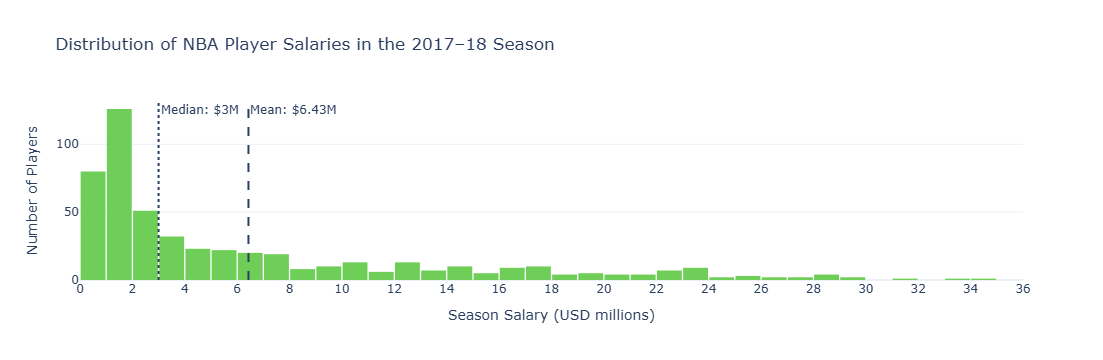

In [1373]:
# Create the histogram for the visualization
fig = px.histogram(
    salary_2018,
    x='salary_millions',
    title='Distribution of NBA Player Salaries in the 2017–18 Season',
)
fig.update_traces(
    xbins={
        'start': 0,
        'end': 36,
        'size': 1
    },
    hovertemplate='Salary range: %{x}<br>Number of players: %{y}<extra></extra>'
)
fig.add_vline(
    x=mean_salary,
    line_dash='dash',
    annotation_text=f'Mean: ${mean_salary:.2f}M',
    annotation_position='top right'
)
fig.add_vline(
    x=median_salary,
    line_dash='dot',
    annotation_text=f'Median: ${median_salary:.0f}M',
    annotation_position='top right'
)
fig.update_layout(
    xaxis_title='Season Salary (USD millions)',
    yaxis_title='Number of Players',
    bargap=0.05,
    template='plotly_white',
    xaxis={
        'range': [0, 36],
        'dtick': 2
    }
)
fig.show()

### Insight/Answer:
#### - The distribution of NBA player salaries in the 2017-18 season is heavily right-skewed. Most players are concentrated around the lower salary     ranges, especially around the $1-2 million mark. 

#### - Progressively fewer players received salaries at the upper end of the distribution, with salaries extending all the way to around $35 million, creating a long right sided tail on the histogram.
#### - This trend is further shown in the large difference between mean and median salary, indicating that a small number of highly paid players pulled    the average up. 
#### Therefore, NBA salaries are distributed unevenly, and the median provides a much better indication of the salary earned by a typical player than the mean.

## 3.2 How have salaries changed across seasons?

In [1376]:
# Calculate the salary statistics for each season
salary_trend = (season_salaries.groupby(['season_start', 'season'], as_index=False)
    .agg(
        mean_salary=('season_salary_total', 'mean'),
        median_salary=('season_salary_total', 'median'),
        number_of_players=('player_id', 'nunique')
    )
    .sort_values('season_start')
)

salary_trend.head()

,season_start,season,mean_salary,median_salary,number_of_players
0,1984,1984-85,398804.761905,302500.0,210
1,1985,1985-86,371357.983051,260000.0,295
2,1986,1986-87,543033.325000,495833.5,40
3,1987,1987-88,459204.313531,339250.0,303
4,1988,1988-89,528010.975078,380000.0,321


In [1377]:
# Convert salary to millions
salary_trend['mean_salary_millions'] = (salary_trend['mean_salary'] / 1_000_000)
salary_trend['median_salary_millions'] = (salary_trend['median_salary'] / 1_000_000)

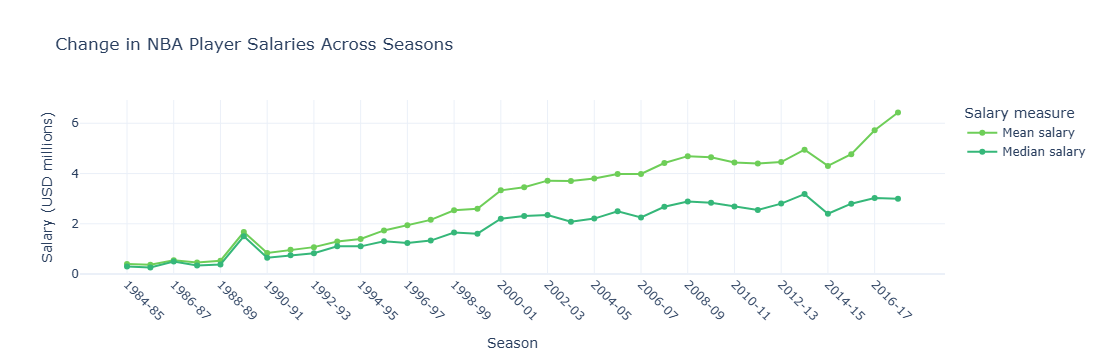

In [1378]:
# Rename columns 
salary_trend_plot = salary_trend.rename(columns={'mean_salary_millions': 'Mean salary','median_salary_millions': 'Median salary'})

# Plot the line graph
fig = px.line(
    salary_trend_plot,
    x='season',
    y=['Mean salary', 'Median salary'],
    markers=True,
    title='Change in NBA Player Salaries Across Seasons'
)
fig.update_layout(
    xaxis={
        'title': 'Season',
        'type': 'category',
        'categoryorder': 'array',
        'categoryarray': salary_trend_plot['season'].tolist(),
        'tickmode': 'array',
        'tickvals': salary_trend_plot['season'].iloc[::2],
        'ticktext': salary_trend_plot['season'].iloc[::2],
        'tickangle': 45
    },
    yaxis={
        'title': 'Salary (USD millions)',
        'rangemode': 'tozero'
    },
    legend_title='Salary measure',
    template='plotly_white',
    hovermode='x unified'
)
fig.show()

### Insight/Answer:
#### - NBA salaries generally increased across the seasons in the dataset, with both mean and median showing a clear long-term upward trend.
#### - The mean remained above the median throughout the entire period, supporting the trend observed in the previous visualisation.
#### - The gap between the two also became wider over time, suggesting that top player salaries increased more rapidly than typical player salaries.
#### - The only limitation of this is that the salaries are reported in nominal dollars and are not adjusted for inflation.

## 3.3 What is the relationship between salary and overall player performance?

#### For this we will examine the 2017-18 season and use career PER as our measurement for performance

In [1382]:
# Create a new dataframe for this question
q3 = nba[
    [
        'player_id',
        'name',
        'position',
        'career_PER',
        'career_G',
        'max_season_salary',
        'last_salary_year'
    ]
].copy()

In [1383]:
q3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2408 entries, 0 to 2407
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   player_id          2408 non-null   object
 1   name               2408 non-null   object
 2   position           2408 non-null   object
 3   career_PER         2408 non-null   object
 4   career_G           2408 non-null   int64 
 5   max_season_salary  2408 non-null   int64 
 6   last_salary_year   2408 non-null   int64 
dtypes: int64(3), object(4)
memory usage: 131.8+ KB


In [1384]:
# We must ensure PER is numeric, convert salary to millions and drop missing values
q3['career_PER'] = pd.to_numeric(q3['career_PER'], errors='coerce')
q3['max_salary_millions'] = (q3['max_season_salary'] / 1_000_000)
q3 = q3.dropna(subset=['career_PER', 'max_salary_millions'])

In [1505]:
# Filter out players with less than 50 career games
q3_filtered = q3.loc[q3['career_G'] >= 50].copy()

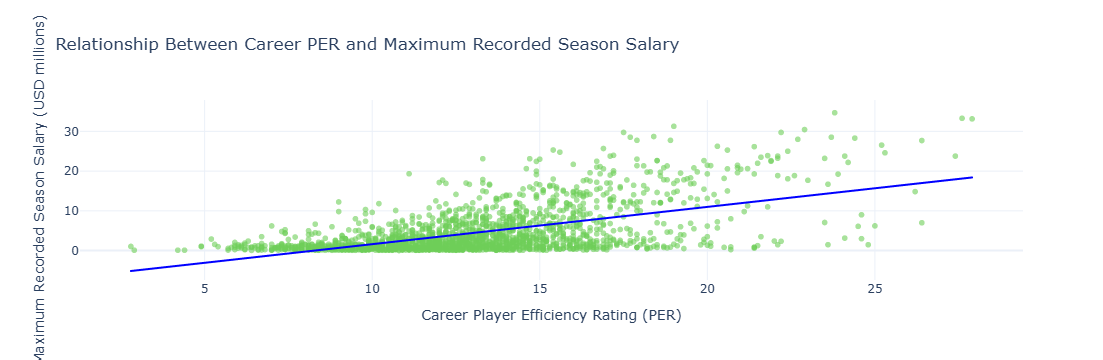

In [1507]:
fig = px.scatter(
    q3_filtered,
    x='career_PER',
    y='max_salary_millions',
    trendline='ols',
    trendline_color_override='blue',
    hover_name='name',
    hover_data={
        'position': True,
        'career_G': True,
        'career_PER': ':.1f',
        'max_salary_millions': ':.2f',
        'last_salary_year': True
    },
    opacity=0.6,
    title=(
        'Relationship Between Career PER and '
        'Maximum Recorded Season Salary'
    ),
    labels={
        'career_PER': 'Career Player Efficiency Rating (PER)',
        'max_salary_millions': (
            'Maximum Recorded Season Salary (USD millions)'
        ),
        'career_G': 'Career games',
        'last_salary_year': 'Last recorded salary year',
        'position': 'Position'
    }
)

fig.update_layout(
    template='plotly_white',
    yaxis={
        'rangemode': 'tozero'
    }
)

fig.show()

In [1387]:
salary_per_correlation = q3_filtered['career_PER'].corr(q3_filtered['max_salary_millions'])
salary_per_correlation

0.5674123274968885

### Insight/Answer:
#### - There is a moderate positive relationship between overall player performance and salary in the 2017-18 season.
#### - This indicates that players with a higher career PER generally tend to earn higher salaries.
#### - However, the points remain widely concentrated, particularly among players with a PER between around 10 and 20.

## 3.4 Which teams had the highest total payroll in the 2017-18 season?

In [1390]:
# Create a new dataframe for this question
q4 = salaries.loc[salaries['season'] == '2017-18'].copy()

In [1391]:
# Calculate total payroll for each team
team_payroll_2018 = (
    q4.groupby('team', as_index=False)
    .agg(
        total_payroll=('salary', 'sum'),
        number_of_salary_records=('player_id', 'size'),
        number_of_players=('player_id', 'nunique')
    )
    .sort_values('total_payroll', ascending=False)
)

In [1392]:
# Convert to millions and select only the top 10 teams
team_payroll_2018['payroll_millions'] = (team_payroll_2018['total_payroll'] / 1_000_000)
top_10_payrolls = team_payroll_2018.head(10).copy()

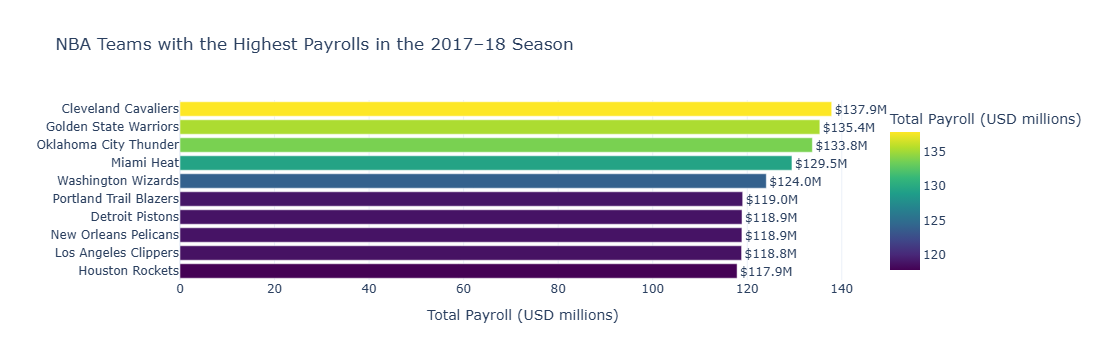

In [1393]:
# Create the bar chart
fig = px.bar(
    top_10_payrolls,
    x='payroll_millions',
    y='team',
    color='payroll_millions',
    color_continuous_scale='Viridis',
    orientation='h',
    title='NBA Teams with the Highest Payrolls in the 2017–18 Season',
    labels={
        'payroll_millions': 'Total Payroll (USD millions)',
        'team': 'Team'
    },
    text='payroll_millions',
    hover_data={
        'total_payroll': False,
        'payroll_millions': ':.2f',
        'number_of_players': True
    }
)
fig.update_traces(
    texttemplate='$%{text:.1f}M',
    textposition='outside',
    cliponaxis=False
)
fig.update_layout(
    template='plotly_white',
    yaxis={
        'categoryorder': 'total ascending',
        'title': ''
    },
    xaxis={
        'title': 'Total Payroll (USD millions)',
        'rangemode': 'tozero'
    },
    showlegend=False
)
fig.show()

### Insight/Answer:
#### - The Cleveland Cavaliers had the highest total payroll in the 2017-18 season at around $137.9M

#### - This was closely followed by the Golden State Warriors at around $135.4M
#### - Interestingly, these were the two teams that reached the finals this season.

## 3.5 Which individual performance statistic is most strongly correlated with highest salary earned?

In [1396]:
performance_stats = [
    'career_PER',
    'career_PTS',
    'career_AST',
    'career_TRB',
    'career_FG%',
    'career_FG3%',
    'career_FT%',
    'career_eFG%',
    'career_G'
]

In [1397]:
# Create a new dataframe for this question
q5 = nba[['player_id', 'name', 'max_season_salary'] + performance_stats].copy()

# Convert salary to millions
q5['max_salary_millions'] = (q5['max_season_salary'] / 1_000_000)

In [1398]:
# Ensure that stats are all numeric
q5[performance_stats] = q5[performance_stats].apply(pd.to_numeric, errors='coerce')

In [1399]:
# Filter out players with less than 20 career games
q5_filtered = q5.loc[q5['career_G'] >= 20].copy()

In [1400]:
# Calculate the correlation
stat_correlations = q5_filtered[performance_stats].corrwith(q5_filtered['max_salary_millions'])

In [1401]:
# Create a table containing the correlations and valid sample sizes
correlation_table = pd.DataFrame({
    'correlation': stat_correlations,
    'players_used': q5_filtered[performance_stats].notna().sum()
})

# Rank statistics by the absolute strength of their correlation
correlation_table = correlation_table.reindex(
    correlation_table['correlation']
    .abs()
    .sort_values(ascending=False)
    .index
)

In [1402]:
# Increase the readability of statistics
statistic_names = {
    'career_PER': 'Player efficiency rating',
    'career_PTS': 'Points per game',
    'career_AST': 'Assists per game',
    'career_TRB': 'Rebounds per game',
    'career_FG%': 'Field-goal percentage',
    'career_FG3%': 'Three-point percentage',
    'career_FT%': 'Free-throw percentage',
    'career_eFG%': 'Effective FG percentage',
    'career_G': 'Career games played'
}

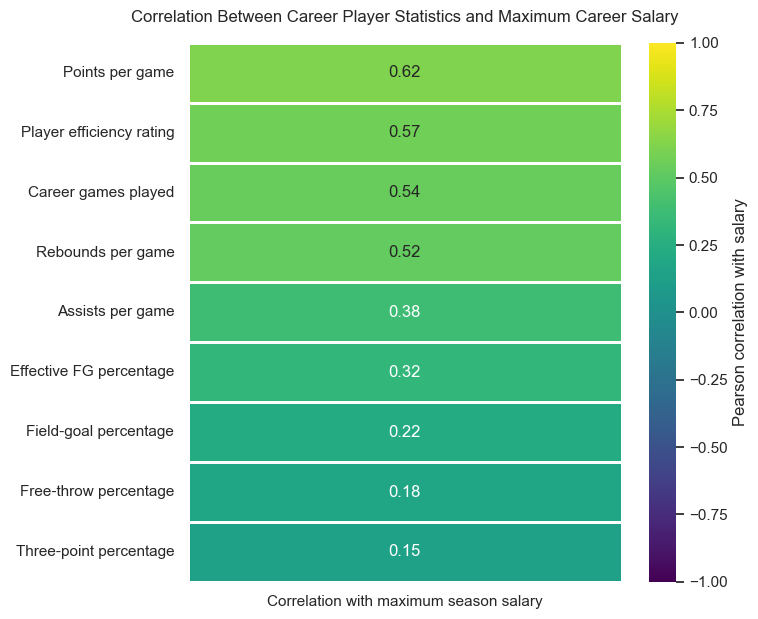

In [1403]:
heatmap_data = correlation_table[['correlation']].copy()

# Create the heatmap
heatmap_data = heatmap_data.rename(
    index=statistic_names
)
heatmap_data.columns = ['Correlation with maximum season salary']
ax = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor='white',
    cbar_kws={
        'label': 'Pearson correlation with salary'
    }
)
ax.figure.set_size_inches(7, 7)
ax.set_title('Correlation Between Career Player Statistics and Maximum Career Salary', pad=15)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=0
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
);

### Insight/Answer:
#### - Points per game had the strongest correlation with maximum season salary, with a Pearson correlation of around 0.62.
#### - Shooting percentages had noticeably the weakest relationships with salary.
#### Therefore, salary appears to be more closely correlated with high-volume production, particularly scoring, rather than shooting efficiency.

## 3.6 What is the relationship between the player's draft position and their salary?

In [1406]:
# Create a new dataframe for this question
q6 = nba[
    [
        'player_id',
        'name',
        'draft_pick',
        'max_season_salary'
    ]
].copy()

In [1407]:
# Extract the number of the draft pick
q6['draft_position'] = pd.to_numeric(
    q6['draft_pick']
        .astype('string')
        .str.extract(r'(\d+)', expand=False),
    errors='coerce'
)

In [1408]:
# Ensure that it is numeric, convert salary to millions and drop missing values
q6['max_salary_millions'] = (
    q6['max_season_salary'] / 1_000_000
)
q6_filtered = q6.dropna(
    subset=['draft_position', 'max_salary_millions']
).copy()

In [1409]:
# Create groups of draft picks for better visualisation
q6_filtered['draft_group'] = pd.cut(
    q6_filtered['draft_position'],
    bins=[
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
        20, 30, 60, float('inf')
    ],
    labels=[
        '1', '2', '3', '4', '5',
        '6', '7', '8', '9', '10',
        '11–20', '21–30', '31–60', '61+'
    ]
)

In [1410]:
# Calculate median salary by group
draft_salary_summary = (
    q6_filtered.groupby(
        'draft_group',
        observed=False,
        as_index=False
    )
    .agg(
        median_salary_millions=(
            'max_salary_millions',
            'median'
        ),
        mean_salary_millions=(
            'max_salary_millions',
            'mean'
        ),
        number_of_players=(
            'player_id',
            'nunique'
        )
    )
)

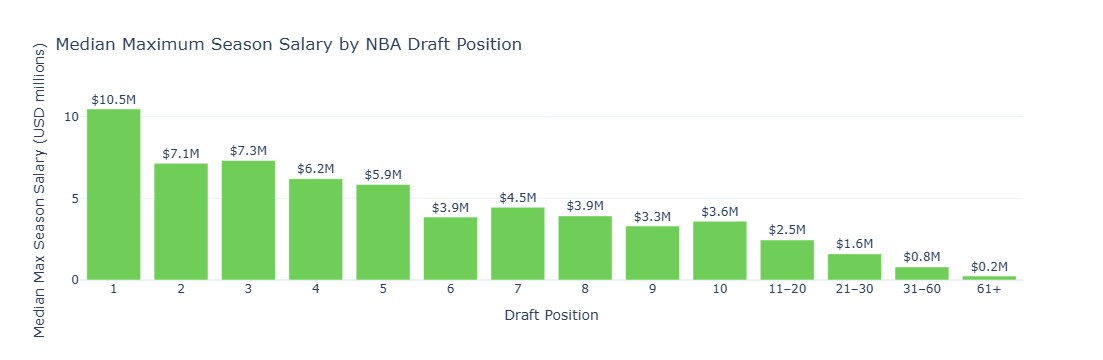

In [1411]:
fig = px.bar(
    draft_salary_summary,
    x='draft_group',
    y='median_salary_millions',
    text='median_salary_millions',
    title='Median Maximum Season Salary by NBA Draft Position',
    labels={
        'draft_group': 'Draft Position',
        'median_salary_millions': (
            'Median Maximum Season Salary (USD millions)'
        )
    },
    hover_data={
        'mean_salary_millions': ':.2f',
        'number_of_players': True
    }
)
fig.update_traces(
    texttemplate='$%{text:.1f}M',
    textposition='outside',
    cliponaxis=False
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='Draft Position',
    yaxis={
        'title': 'Median Max Season Salary (USD millions)',
        'rangemode': 'tozero'
    },
    showlegend=False
)
fig.show()

### Insight/Answer:
#### - This visualisation indicates a negative relationship between draft position and maximum season salary, meaning that the earlier the player was picked in the NBA draft, the more their higher max season salary was.
#### - Early draft picks also displayed a much wider salary distribution, some reached maximum salaries above $30 million, while players selected later were increasingly concentrated at lower salary levels.

## 3.7 How does the player's age relate to their salary and performance?

In [1414]:
# Find each player's highest-paid season
q7 = season_salaries.loc[
    season_salaries.groupby('player_id')[
        'season_salary_total'
    ].idxmax()
].copy()

In [1415]:
# Keep the relevant salary columns
q7 = q7[
    [
        'player_id',
        'season',
        'season_start',
        'season_end',
        'season_salary_total'
    ]
].copy()

In [1416]:
# Merge player information from nba dataframe
q7 = q7.merge(
    nba[
        [
            'player_id',
            'name',
            'birthDate',
            'position',
            'career_PER',
            'career_G'
        ]
    ],
    on='player_id',
    how='left'
)

In [1417]:
# Convert birthDate to datetime
q7['birthDate'] = pd.to_datetime(
    q7['birthDate'],
    errors='coerce'
)

# Convert career_PER to numeric
q7['career_PER'] = pd.to_numeric(
    q7['career_PER'],
    errors='coerce'
)

In [1418]:
# Calculate approximate age during the maximum-salary season
q7['age_at_max_salary'] = (
    q7['season_start']
    - q7['birthDate'].dt.year
)

In [1419]:
# Convert salary to millions and drop missing values
q7['max_salary_millions'] = (q7['season_salary_total'] / 1_000_000)
q7_filtered = q7.dropna(
    subset=[
        'age_at_max_salary',
        'max_salary_millions',
        'career_PER'
    ]
).copy()

In [1420]:
# Ensure bubble sizes are positive and data is filtered
q7_filtered['bubble_size'] = (q7_filtered['career_PER'] - q7_filtered['career_PER'].min() + 1)
# Filter for min 500 games played as data is too cluttered otherwise
q7_plot = q7_filtered[(q7_filtered['career_G'] >= 500) & (q7_filtered['career_PER'].between(0, 35))].copy()

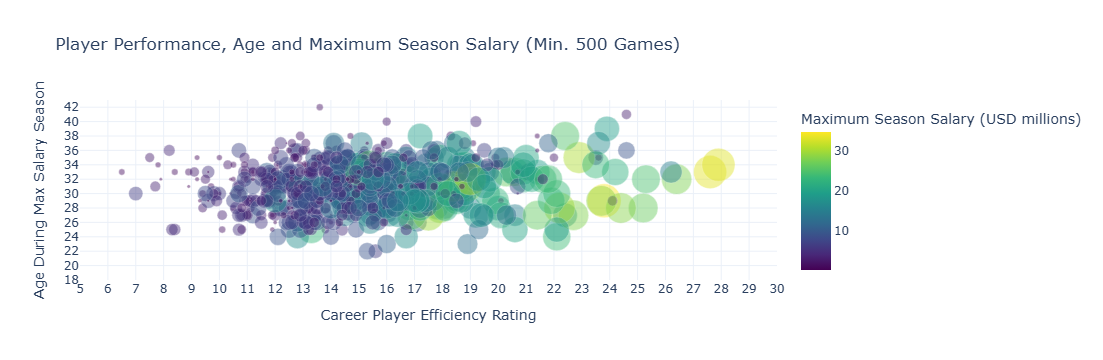

In [1421]:
# Create the bubble plot
fig = px.scatter(
    q7_plot,
    x='career_PER',
    y='age_at_max_salary',
    size='max_salary_millions',
    color='max_salary_millions',
    hover_name='name',
    hover_data={
        'position': True,
        'career_G': True,
        'season': True,
        'career_PER': ':.1f',
        'age_at_max_salary': True,
        'max_salary_millions': ':.2f'
    },
    size_max=24,
    opacity=0.45,
    color_continuous_scale='Viridis',
    title='Player Performance, Age and Maximum Season Salary (Min. 500 Games)',
    labels={
        'career_PER': 'Career Player Efficiency Rating',
        'age_at_max_salary': 'Age During Max Salary Season',
        'max_salary_millions': 'Maximum Season Salary (USD millions)',
        'career_G': 'Career Games'
    }
)
fig.update_traces(
    marker={
        'line': {
            'width': 0.4,
            'color': 'white'
        }
    }
)
fig.update_layout(
    template='plotly_white',
    xaxis={
        'range': [5, 30],
        'dtick': 1
    },
    yaxis={
        'range': [18, 43],
        'dtick': 2
    }
)
fig.show()

### Insight/Answer:
#### - The visualisation suggests that player performance (Career PER) has a stronger relationship with maximum salary than age does.
#### - Most players earned their maximum salary between approximately 27 and 35 years old, regardless of performance level.
#### - The chart also shows that high performance does not guarantee the highest salary. Players with similar Career PER values can have noticeably different maximum salaries.

## 3.8 Do salaries differ by the player's position?

In [1424]:
# Use the player's primary position and put them in order
nba['primary_position'] = nba['position'].str.split(' and ').str[0]

position_order = [
    'Point Guard',
    'Shooting Guard',
    'Small Forward',
    'Power Forward',
    'Center'
]

In [1425]:
# Create a new dataframe for this question
q8 = nba[
    [
        'player_id',
        'name',
        'primary_position',
        'median_salary',
        'max_season_salary',
        'salary_seasons'
    ]
].copy()

In [1426]:
# Convert to millions and drop missing values
q8['median_salary_millions'] = (
    q8['median_salary'] / 1_000_000
)

q8 = q8.dropna(
    subset=['primary_position', 'median_salary_millions']
)

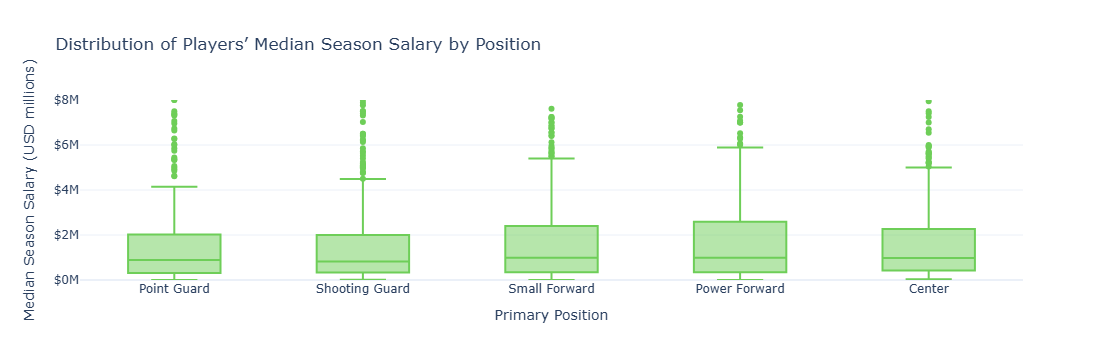

In [1427]:
# Create the box plot
fig = px.box(
    q8,
    x='primary_position',
    y='median_salary_millions',
    category_orders={
        'primary_position': position_order
    },
    points='outliers',
    hover_name='name',
    hover_data={
        'median_salary_millions': ':.2f',
        'salary_seasons': True,
        'primary_position': False
    },
    title='Distribution of Players’ Median Season Salary by Position',
    labels={
        'primary_position': 'Position',
        'median_salary_millions': (
            'Median Season Salary (USD millions)'
        ),
        'salary_seasons': 'Recorded salary seasons'
    }
)

fig.update_layout(
    template='plotly_white',
    yaxis={
        'rangemode': 'tozero',
        'dtick': 2,
        'tickprefix': '$',
        'ticksuffix': 'M'
    },
    xaxis_title='Primary Position',
    showlegend=False
)
fig.update_yaxes(range=[0, 8])
fig.show()

### Insight/Answer:
#### - The distributions are broadly similar across all five positions, with substantial overlap in their medians and interquartile ranges. This suggests that player position does not produce a large difference in typical salary.
#### - However, there are some smaller differences such as forwards having lightly higher median salaries and wider upper ranges and guards having slightly lower median salaries.
#### - The strong right skew once again indicates that a relatively small number of players earn substantially more than the typical player in each position.

## 3.9 Which performance metrics are most strongly related to each other?

In [1430]:
q9_stats = [
    'career_PER',
    'career_PTS',
    'career_AST',
    'career_TRB',
    'career_FG%',
    'career_FG3%',
    'career_FT%',
    'career_eFG%'
]

In [1431]:
# Create a new dataframe for this question
q9 = nba[['player_id', 'name', 'career_G'] + q9_stats].copy()

In [1432]:
# Convert games played to numeric first
q9['career_G'] = pd.to_numeric(
    q9['career_G'],
    errors='coerce'
)

In [1433]:
# Filter out players with less than 20 career games
q9_filtered = q9.loc[q9['career_G'] >= 20].copy()

In [1434]:
# Convert the performance columns to numeric
q9_filtered[q9_stats] = q9_filtered[q9_stats].apply(
    pd.to_numeric,
    errors='coerce'
)

In [1435]:
# Calculate the correlation
performance_correlation = q9_filtered[q9_stats].corr()

In [1436]:
# Use shorter names so heatmap is not crowded
q9_statistic_names = {
    'career_PER': 'PER',
    'career_PTS': 'Points',
    'career_AST': 'Assists',
    'career_TRB': 'Rebounds',
    'career_FG%': 'FG%',
    'career_FG3%': '3P%',
    'career_FT%': 'FT%',
    'career_eFG%': 'eFG%'
}
# Apply the names
performance_correlation = performance_correlation.rename(index=q9_statistic_names, columns=q9_statistic_names)

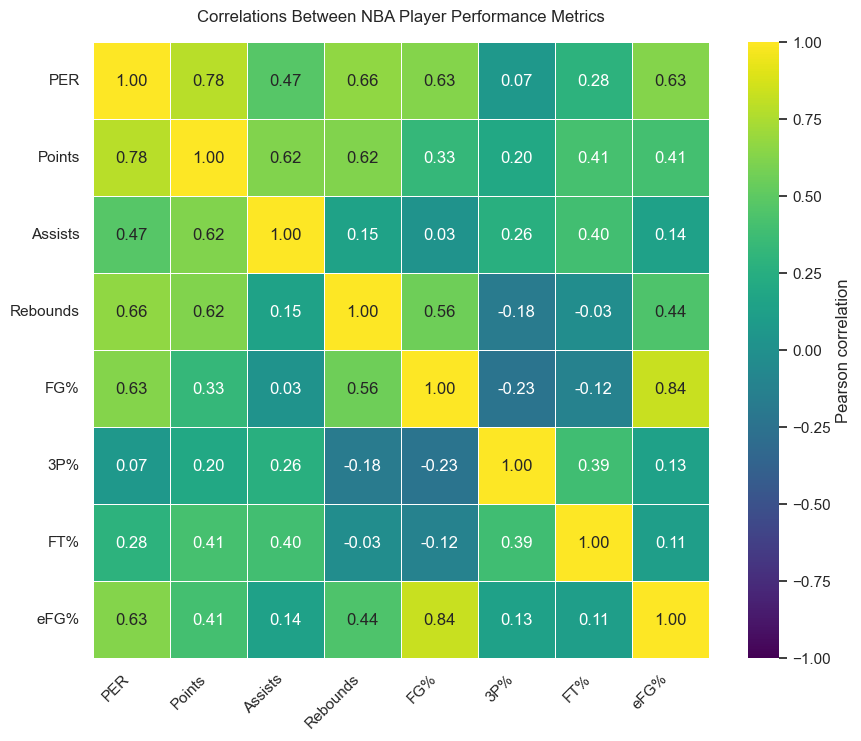

In [1437]:
# Create the heatmap
ax = sns.heatmap(
    performance_correlation,
    annot=True,
    fmt='.2f',
    cmap='viridis',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={
        'label': 'Pearson correlation'
    }
)
ax.figure.set_size_inches(10, 8)
ax.set_title(
    'Correlations Between NBA Player Performance Metrics',
    pad=15
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha='right'
)
ax.set_yticklabels(
    ax.get_yticklabels(),
    rotation=0
);

### Insight/Answer:
#### - The most strongly related performance metrics are field-goal percentage and effective field-goal percentage, followed by PER and points.
#### - Metrics such as three-point percentage and assists show weaker relationships with many other variables, suggesting that they represent more specialised aspects of a player’s role.
#### - Overall, the heatmap shows that scoring and shooting-efficiency measures tend to move together, while some skills remain relatively independent.

## 3.10 Can players be grouped into distinct performance profiles?

In [1440]:
# Select relevant stats and create a new dataframe for this question
q10_stats = [
    'career_G',
    'career_PTS',
    'career_AST',
    'career_TRB',
    'career_PER'
]

q10 = nba[
    [
        'player_id',
        'name',
        'primary_position'
    ] + q10_stats
].copy()

In [1441]:
# Ensure everything is numeric
q10[q10_stats] = q10[q10_stats].apply(pd.to_numeric, errors='coerce')

In [1442]:
# Filter unreliable observations
q10_filtered = q10.loc[
    (q10['career_G'] >= 20)
].dropna(
    subset=[
        'career_PTS',
        'career_AST',
        'career_TRB'
    ]
).copy()

In [1443]:
# Calculate medians
median_assists = q10_filtered['career_AST'].median()
median_rebounds = q10_filtered['career_TRB'].median()

In [1444]:
# Assign each player a performance profile
def assign_performance_profile(player):
    
    if (
        player['career_AST'] >= median_assists
        and player['career_TRB'] >= median_rebounds
    ):
        return 'All-round contributors'
    
    elif (
        player['career_AST'] >= median_assists
        and player['career_TRB'] < median_rebounds
    ):
        return 'Playmakers'
    
    elif (
        player['career_AST'] < median_assists
        and player['career_TRB'] >= median_rebounds
    ):
        return 'Rebounders / interior players'
    
    else:
        return 'Lower-volume role players'

q10_filtered['performance_profile'] = q10_filtered.apply(
    assign_performance_profile,
    axis=1
)

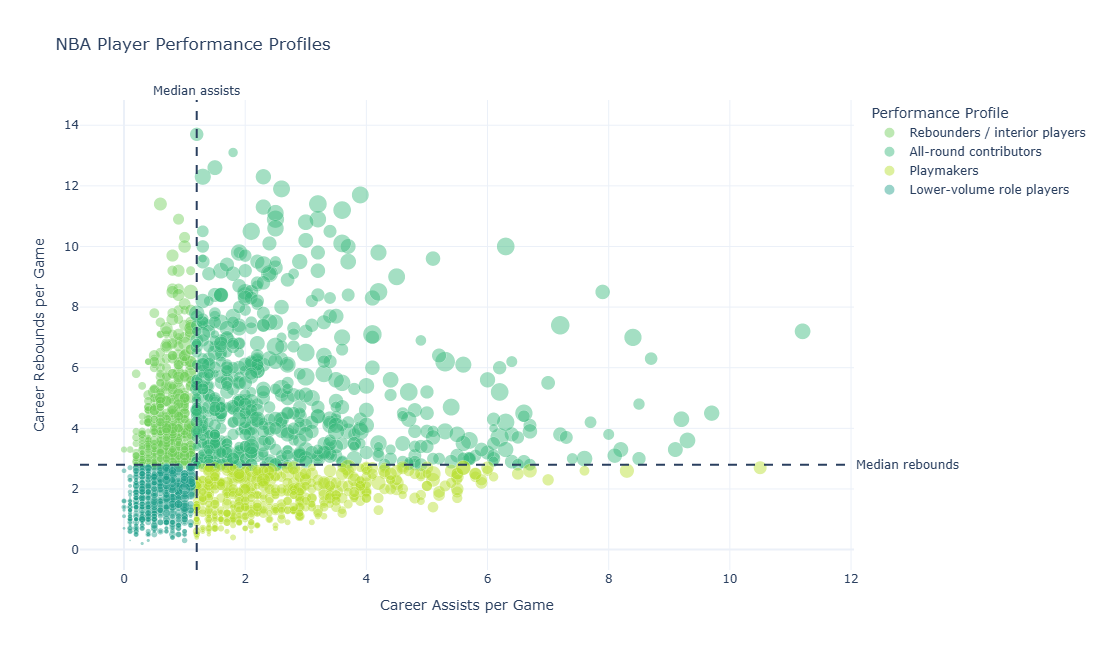

In [1445]:
# Create the bubble chart
fig = px.scatter(
    q10_filtered,
    x='career_AST',
    y='career_TRB',
    size='career_PTS',
    color='performance_profile',
    hover_name='name',
    hover_data={
        'primary_position': True,
        'career_PTS': ':.1f',
        'career_AST': ':.1f',
        'career_TRB': ':.1f',
        'career_PER': ':.1f',
        'performance_profile': False
    },
    size_max=20,
    title='NBA Player Performance Profiles',
    labels={
        'career_AST': 'Career Assists per Game',
        'career_TRB': 'Career Rebounds per Game',
        'career_PTS': 'Career Points per Game',
        'career_PER': 'Career PER',
        'primary_position': 'Primary Position',
        'performance_profile': 'Performance Profile'
    }
)

fig.update_layout(
    template='plotly_white',
    height=650,
    legend_title_text='Performance Profile'
)

fig.update_traces(
    marker={
        'opacity': 0.45,
        'line': {
            'width': 0.3
        }
    }
)
fig.add_vline(
    x=median_assists,
    line_dash='dash',
    line_width=2,
    annotation_text='Median assists',
    annotation_position='top'
)

fig.add_hline(
    y=median_rebounds,
    line_dash='dash',
    line_width=2,
    annotation_text='Median rebounds',
    annotation_position='right'
)

fig.show()

### Insight/Answer:
#### - Players can be grouped into four broad performance profiles based on whether their career assists and rebounds are above or below the dataset medians.
#### - Playmaking and rebounding appear to be trade-offs, players with very high assists often have relatively low rebounds and vice-versa.
#### - The highest scorers tend to be versatile contributors, many of the largest bubbles occur in the upper-right quadrant.